# Laboratorio 9
- Marco Vinicio Ramirez Centes 21032
- Josué Isaac Morales González 21116

### Temperatura global desde 1880 hasta 2023

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

In [ ]:
# Especificar la ruta del archivo
file_path = './hola.csv'

# Cargar el archivo CSV, omitiendo las primeras dos líneas y estableciendo nombres de columnas
column_names = ["Year", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", 
                "Nov", "Dec", "J-D", "D-N", "DJF", "MAM", "JJA", "SON"]
data = pd.read_csv(file_path, skiprows=2, names=column_names)

# Eliminar filas con valores no numéricos y convertir las columnas a valores numéricos
data = data.apply(pd.to_numeric, errors='coerce').dropna()

# Verificar la estructura de los datos
data.head()


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
1,1881,-0.20,-0.15,0.02,0.04,0.07,-0.19,0.01,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-0.10,-0.18,0.04,-0.07,-0.19
2,1882,0.16,0.14,0.04,-0.16,-0.14,-0.22,-0.16,-0.07,-0.14,-0.24,-0.17,-0.36,-0.11,-0.09,0.07,-0.08,-0.15,-0.18
3,1883,-0.29,-0.37,-0.12,-0.18,-0.18,-0.07,-0.07,-0.14,-0.22,-0.12,-0.24,-0.11,-0.18,-0.20,-0.34,-0.16,-0.10,-0.19
4,1884,-0.13,-0.08,-0.37,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29
5,1885,-0.58,-0.34,-0.27,-0.42,-0.45,-0.44,-0.34,-0.31,-0.28,-0.24,-0.24,-0.11,-0.33,-0.35,-0.41,-0.38,-0.36,-0.25


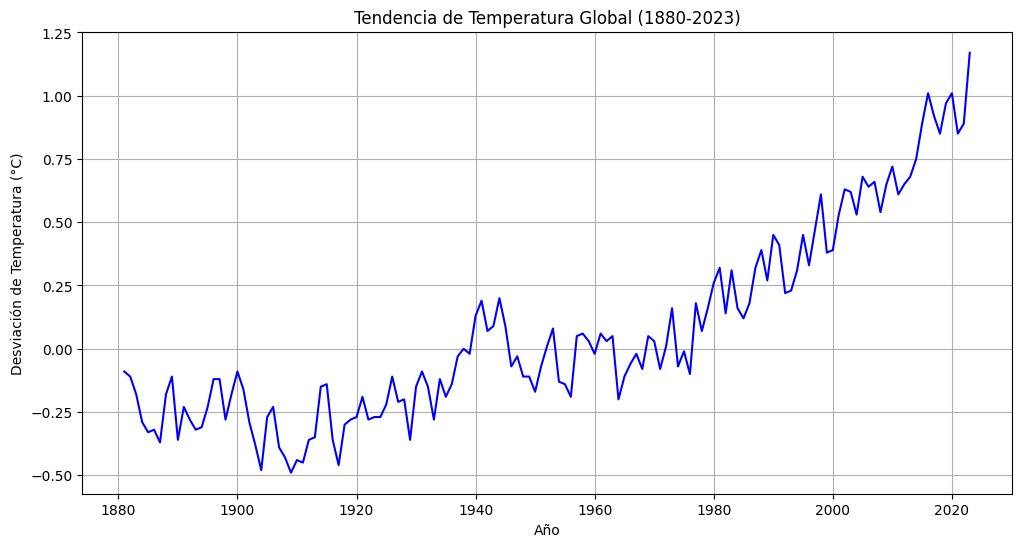

In [ ]:
# Graficar la tendencia de temperatura anual promedio (J-D) a lo largo de los años
plt.figure(figsize=(12, 6))
plt.plot(data["Year"], data["J-D"], color='blue', linewidth=1.5)

# Agregar títulos y etiquetas
plt.title("Tendencia de Temperatura Global (1880-2023)")
plt.xlabel("Año")
plt.ylabel("Desviación de Temperatura (°C)")

# Mostrar la gráfica
plt.grid(True)
plt.show()


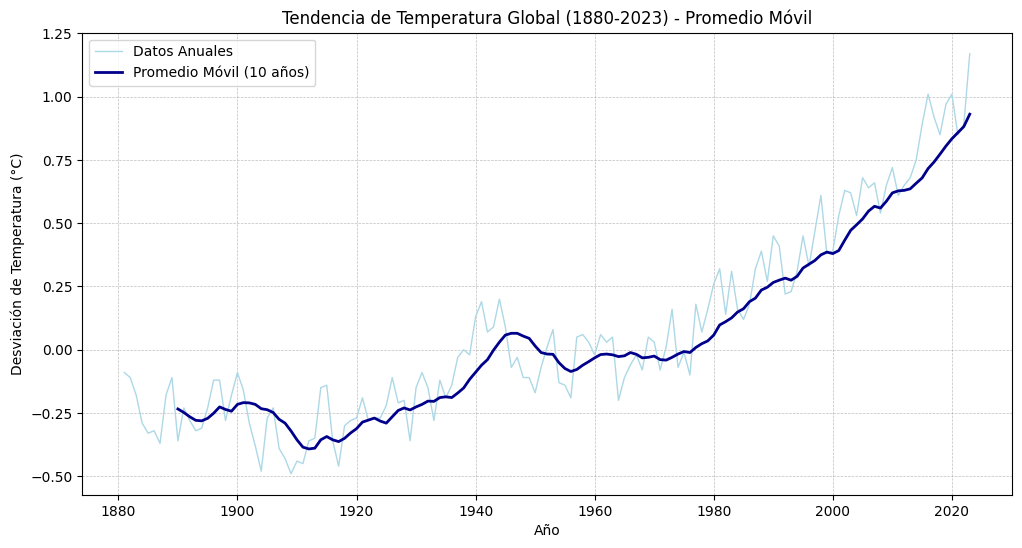

In [ ]:
# Aplicar un promedio móvil para suavizar la línea de tendencia
data["J-D_Moving_Avg"] = data["J-D"].rolling(window=10).mean()

# Crear una gráfica optimizada de la tendencia de temperatura global
plt.figure(figsize=(12, 6))
plt.plot(data["Year"], data["J-D"], color='lightblue', linewidth=1, label="Datos Anuales")
plt.plot(data["Year"], data["J-D_Moving_Avg"], color='darkblue', linewidth=2, label="Promedio Móvil (10 años)")

# Agregar títulos y etiquetas
plt.title("Tendencia de Temperatura Global (1880-2023) - Promedio Móvil")
plt.xlabel("Año")
plt.ylabel("Desviación de Temperatura (°C)")
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)  # Líneas de guía menos intensas
plt.legend()

# Mostrar la gráfica optimizada
plt.show()


#### Justificación

La gráfica de líneas se eligió para representar la tendencia de temperatura global desde 1880, permitiendo observar el cambio gradual en la desviación de temperatura promedio. Para mejorar la claridad y facilitar la comprensión de la tendencia, se aplicó un promedio móvil de 10 años, lo que suaviza las fluctuaciones anuales y destaca mejor el aumento general en las temperaturas globales, especialmente en las últimas décadas.

### Ventas

In [9]:
# Cargar el nuevo dataset "train.csv"
train_file_path = './train.csv'
train_data = pd.read_csv(train_file_path)

# Mostrar las primeras filas para explorar el contenido
train_data.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


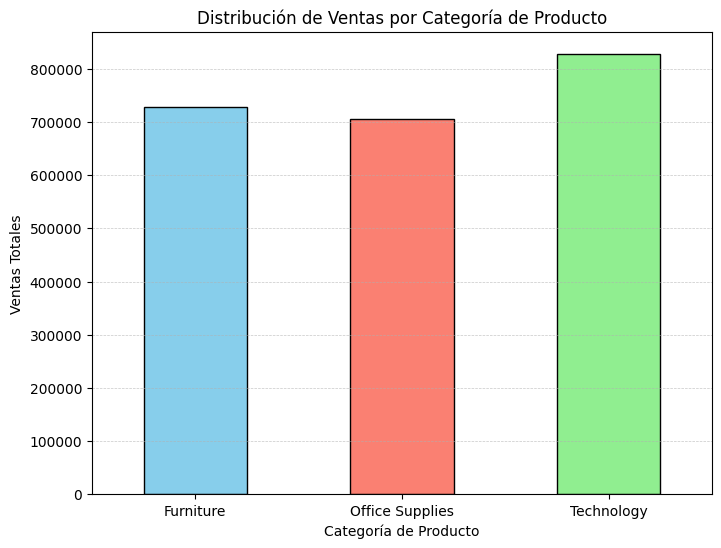

In [10]:
# Agrupar las ventas por categoría de producto
category_sales = train_data.groupby("Category")["Sales"].sum()

# Crear la gráfica de barras para la distribución de ventas por categoría de producto
plt.figure(figsize=(8, 6))
category_sales.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'], edgecolor='black')
plt.title("Distribución de Ventas por Categoría de Producto")
plt.xlabel("Categoría de Producto")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Mostrar la gráfica
plt.show()


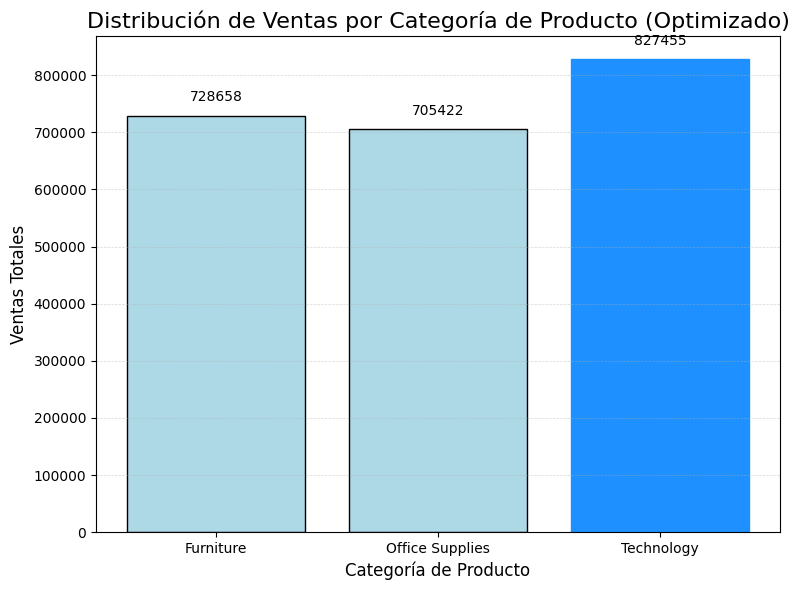

In [11]:
# Crear una gráfica optimizada de la distribución de ventas por categoría de producto
plt.figure(figsize=(8, 6))
bars = plt.bar(category_sales.index, category_sales.values, color='lightblue', edgecolor='black')

# Resaltar la categoría con mayor venta
max_index = category_sales.idxmax()
bars[category_sales.index.get_loc(max_index)].set_color('dodgerblue')

# Agregar etiquetas de valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 20000, f'{int(yval)}', ha='center', va='bottom')

# Títulos y etiquetas
plt.title("Distribución de Ventas por Categoría de Producto (Optimizado)", fontsize=16)
plt.xlabel("Categoría de Producto", fontsize=12)
plt.ylabel("Ventas Totales", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)  # Solo líneas de guía horizontales tenues

# Mostrar la gráfica optimizada
plt.tight_layout()
plt.show()


#### Justificación

La gráfica de barras muestra la distribución de ventas por categoría de producto, facilitando la comparación entre categorías. Para optimizarla, se utilizó un color uniforme y se resaltó la categoría con mayores ventas, además de añadir etiquetas de valor sobre cada barra para una lectura directa. Las líneas de guía tenues en el eje vertical ayudan a la orientación sin distraer. Estos ajustes simplifican la interpretación, reduciendo la carga cognitiva y destacando los datos clave de forma clara.

### Netflix

In [12]:
# Cargar el archivo de Netflix
netflix_file_path = './netflix_titles.csv'
netflix_data = pd.read_csv(netflix_file_path)

# Mostrar las primeras filas para explorar el contenido
netflix_data.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


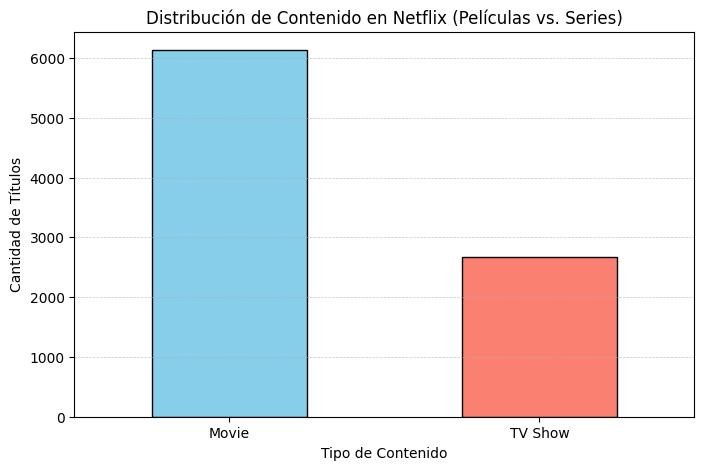

In [13]:
# Contar el número de títulos por tipo de contenido
type_counts = netflix_data['type'].value_counts()

# Crear la gráfica de barras para la distribución por tipo de contenido
plt.figure(figsize=(8, 5))
type_counts.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')
plt.title("Distribución de Contenido en Netflix (Películas vs. Series)")
plt.xlabel("Tipo de Contenido")
plt.ylabel("Cantidad de Títulos")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Mostrar la gráfica
plt.show()


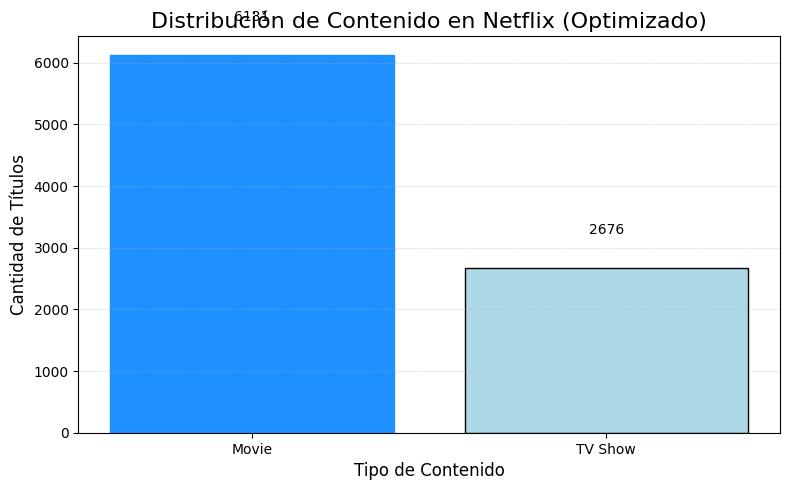

In [14]:
# Crear una versión optimizada de la gráfica de distribución por tipo de contenido
plt.figure(figsize=(8, 5))
bars = plt.bar(type_counts.index, type_counts.values, color='lightblue', edgecolor='black')

# Resaltar la categoría con mayor número de títulos
max_index = type_counts.idxmax()
bars[type_counts.index.get_loc(max_index)].set_color('dodgerblue')

# Agregar etiquetas de valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 500, f'{int(yval)}', ha='center', va='bottom')

# Títulos y etiquetas
plt.title("Distribución de Contenido en Netflix (Optimizado)", fontsize=16)
plt.xlabel("Tipo de Contenido", fontsize=12)
plt.ylabel("Cantidad de Títulos", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)  # Líneas de guía ligeras

# Mostrar la gráfica optimizada
plt.tight_layout()
plt.show()


#### Justificación

La gráfica de barras es una opción adecuada para comparar el número de películas y series en Netflix, permitiendo una visualización clara de la proporción entre ambos tipos de contenido. La versión optimizada utiliza un color uniforme, con la categoría dominante resaltada, para dirigir la atención al grupo más grande sin añadir distracciones. Además, las etiquetas de valores sobre cada barra facilitan una interpretación rápida sin necesidad de estimación visual. Las líneas de guía ligeras mejoran la orientación en el eje vertical sin saturar el gráfico. Estos ajustes hacen que la comparación sea más sencilla y que la información sea captada de forma inmediata.

### Ejercicio 4

In [15]:
# Cargar el archivo de ventas unitarias
sales_file_path = './Depuracion.csv'
sales_data = pd.read_csv(sales_file_path)

# Mostrar las primeras filas para explorar el contenido
sales_data.head()


,Fecha,Ventas Reales (unidades),Ventas planificadas (unidades)
0,Jan-18,50000000.0,NaN
1,Feb-18,42000000.0,NaN
2,Mar-18,44000000.0,NaN
3,Apr-18,43000000.0,NaN
4,May-18,42500000.0,NaN


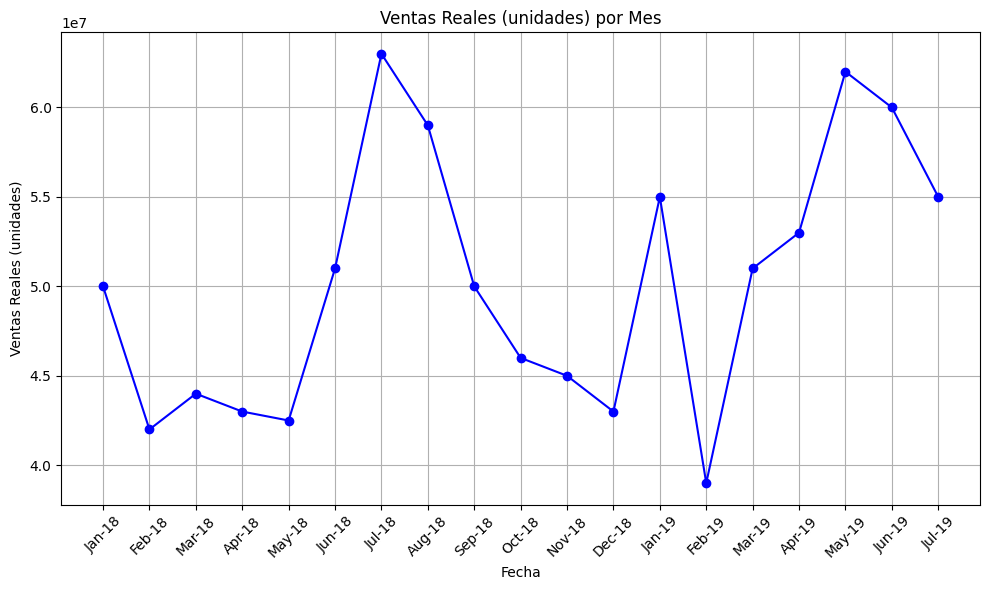

In [16]:
# Crear una gráfica básica de las ventas reales a lo largo del tiempo
plt.figure(figsize=(10, 6))
plt.plot(sales_data["Fecha"], sales_data["Ventas Reales (unidades)"], color='blue', marker='o', linewidth=1.5)
plt.title("Ventas Reales (unidades) por Mes")
plt.xlabel("Fecha")
plt.ylabel("Ventas Reales (unidades)")
plt.xticks(rotation=45)
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()


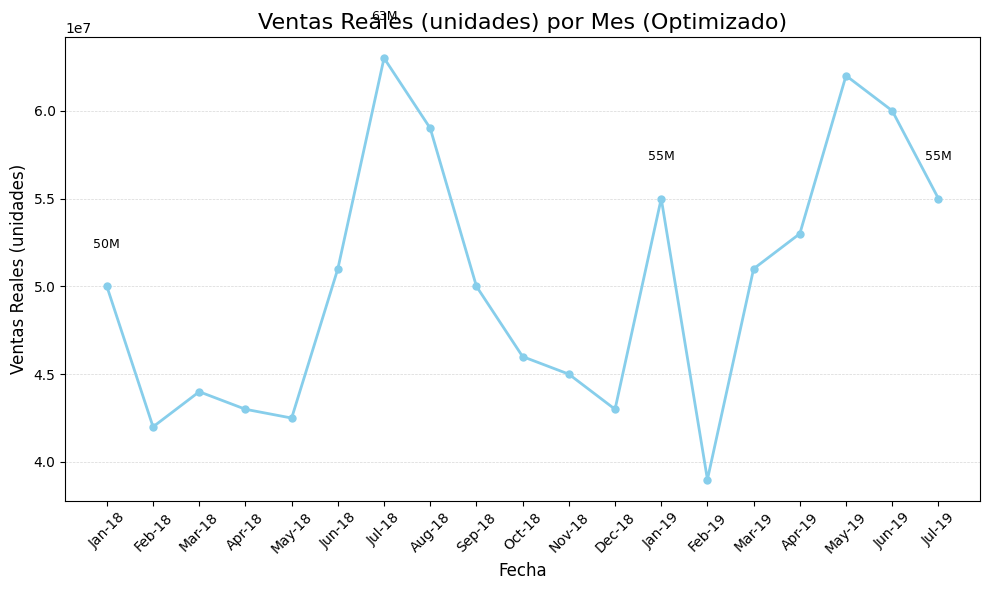

In [17]:
# Crear una versión optimizada de la gráfica de ventas reales
plt.figure(figsize=(10, 6))
plt.plot(sales_data["Fecha"], sales_data["Ventas Reales (unidades)"], color='skyblue', marker='o', markersize=5, linewidth=2)

# Resaltar algunos puntos específicos para facilitar la lectura
for i, (fecha, venta) in enumerate(zip(sales_data["Fecha"], sales_data["Ventas Reales (unidades)"])):
    if i % 6 == 0:  # Mostrar solo cada seis meses para evitar saturación
        plt.text(fecha, venta + 2000000, f'{int(venta / 1000000)}M', ha='center', va='bottom', fontsize=9)

# Títulos y etiquetas
plt.title("Ventas Reales (unidades) por Mes (Optimizado)", fontsize=16)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Ventas Reales (unidades)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)  # Líneas de guía ligeras

# Mostrar la gráfica optimizada
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

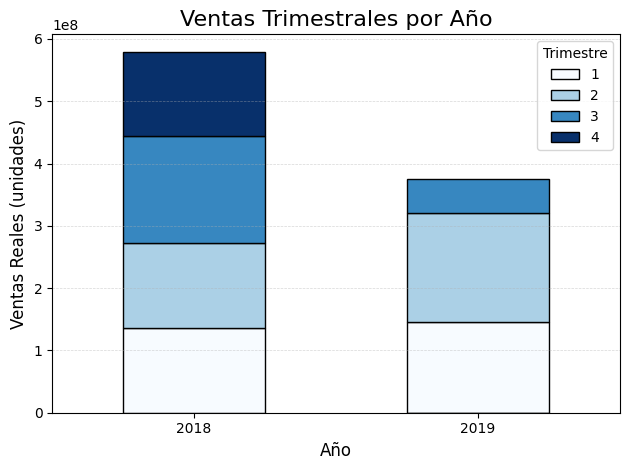

In [21]:
# Intentar convertir la columna de fechas especificando el formato adecuado
sales_data["Fecha"] = pd.to_datetime(sales_data["Fecha"], format="%b-%y")
sales_data["Trimestre"] = sales_data["Fecha"].dt.quarter
sales_data["Año"] = sales_data["Fecha"].dt.year

# Agrupar los datos por trimestre y año y sumar las ventas
quarterly_sales = sales_data.groupby(["Año", "Trimestre"])["Ventas Reales (unidades)"].sum().unstack()

# Crear la gráfica con proximidad y similitud
plt.figure(figsize=(10, 6))
quarterly_sales.plot(kind="bar", stacked=True, colormap="Blues", edgecolor="black")

# Títulos y etiquetas
plt.title("Ventas Trimestrales por Año", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ventas Reales (unidades)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Trimestre")
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

# Mostrar la gráfica que aplica principios de la Gestalt
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

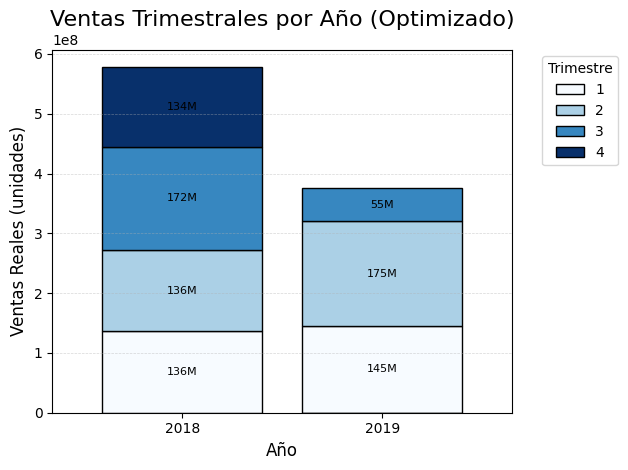

In [22]:

plt.figure(figsize=(10, 6))
bars = quarterly_sales.plot(kind="bar", stacked=True, colormap="Blues", edgecolor="black", width=0.8)

# Títulos y etiquetas
plt.title("Ventas Trimestrales por Año (Optimizado)", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ventas Reales (unidades)", fontsize=12)
plt.xticks(rotation=0)

# Ajuste de leyenda y grid
plt.legend(title="Trimestre", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)  # Grid más ligero

# Etiquetas de valor en las barras superiores para reducir carga cognitiva
for i, year in enumerate(quarterly_sales.index):
    cumulative_height = 0  # Altura acumulada para apilar etiquetas
    for quarter in quarterly_sales.columns:
        sales_value = quarterly_sales.loc[year, quarter]
        if sales_value > 0:
            cumulative_height += sales_value
            plt.text(i, cumulative_height - sales_value / 2, f'{int(sales_value / 1e6)}M', ha='center', va='center', fontsize=8)

# Optimizar el layout
plt.tight_layout()
plt.show()


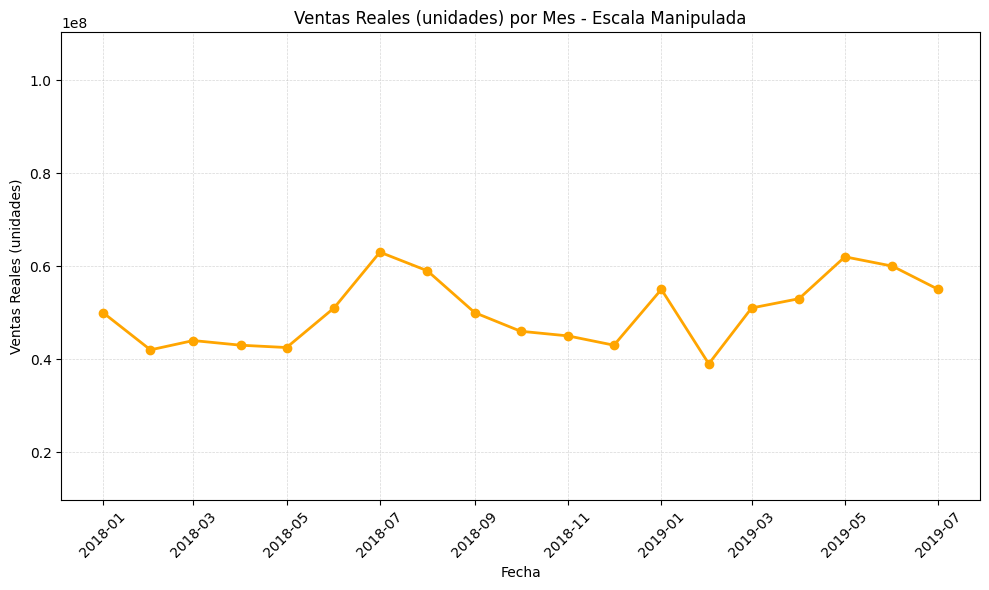

In [27]:
# Crear una versión de la gráfica engañosa con una escala manipulada pero más visible
plt.figure(figsize=(10, 6))
plt.plot(sales_data["Fecha"], sales_data["Ventas Reales (unidades)"], color='orange', marker='o', linewidth=2)

# Ajustar la escala del eje y para exagerar la diferencia, pero mantener los datos visibles
plt.ylim(sales_data["Ventas Reales (unidades)"].min() * 0.25, sales_data["Ventas Reales (unidades)"].max() * 1.75)

# Títulos y etiquetas
plt.title("Ventas Reales (unidades) por Mes - Escala Manipulada")
plt.xlabel("Fecha")
plt.ylabel("Ventas Reales (unidades)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Mostrar la gráfica manipulada con visibilidad adecuada
plt.tight_layout()
plt.show()


Esta gráfica manipula la escala en el eje y al restringirla entre valores más amplios 25% del mínimo y 175% del máximo,lo cual hace parecer que las fluctuaciones de ventas parezcan menos pronunciadas.

Al manipular la escala de esta manera, la gráfica presenta una imagen engañosa de volatilidad, que puede llevar a conclusiones incorrectas sobre la estabilidad de las ventas. Este tipo de manipulación podría usarse para influir en decisiones basadas en una percepción errónea de los datos.

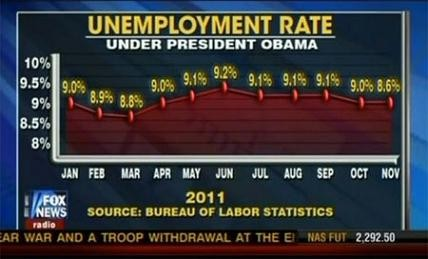

In [ ]:
# Mostrar la imagen
Image(filename='./2016-04-11-9639IBJ5418.jpg')


Un ejemplo notable de una visualización engañosa en los medios de comunicación es un gráfico publicado por Fox News que mostraba la tasa de desempleo en Estados Unidos. En este gráfico, las barras que representaban los porcentajes de desempleo no eran proporcionales a los valores reales; por ejemplo, una barra correspondiente al 8,6% era más alta que otra del 8,9%, lo cual es incorrecto y puede inducir a error al espectador.

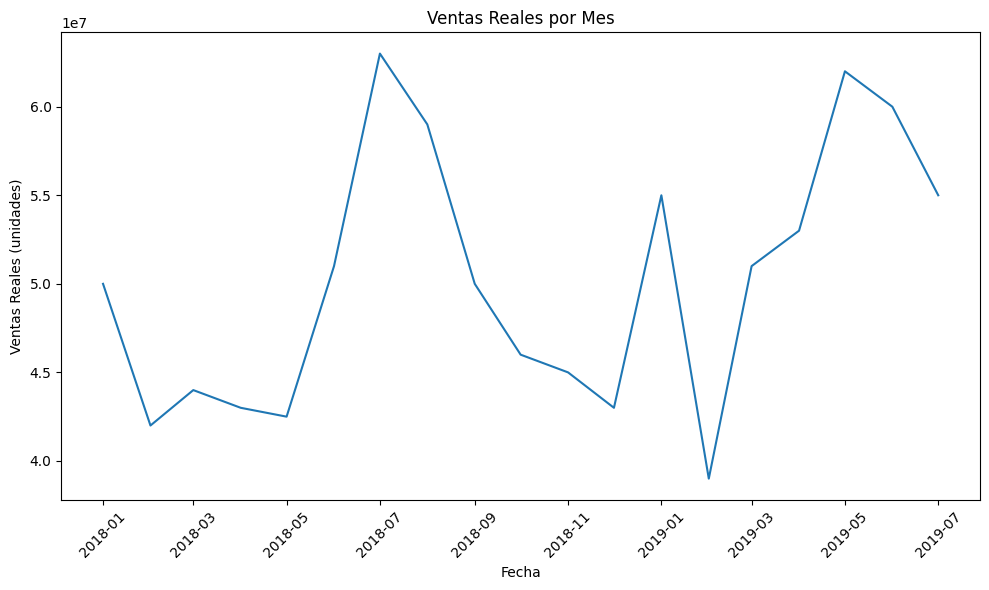

In [30]:
# Visualización básica de las ventas reales a lo largo del tiempo con configuraciones predeterminadas
plt.figure(figsize=(10, 6))
plt.plot(sales_data["Fecha"], sales_data["Ventas Reales (unidades)"])

# Títulos y etiquetas básicas
plt.title("Ventas Reales por Mes")
plt.xlabel("Fecha")
plt.ylabel("Ventas Reales (unidades)")
plt.xticks(rotation=45)

# Mostrar la visualización básica
plt.tight_layout()
plt.show()


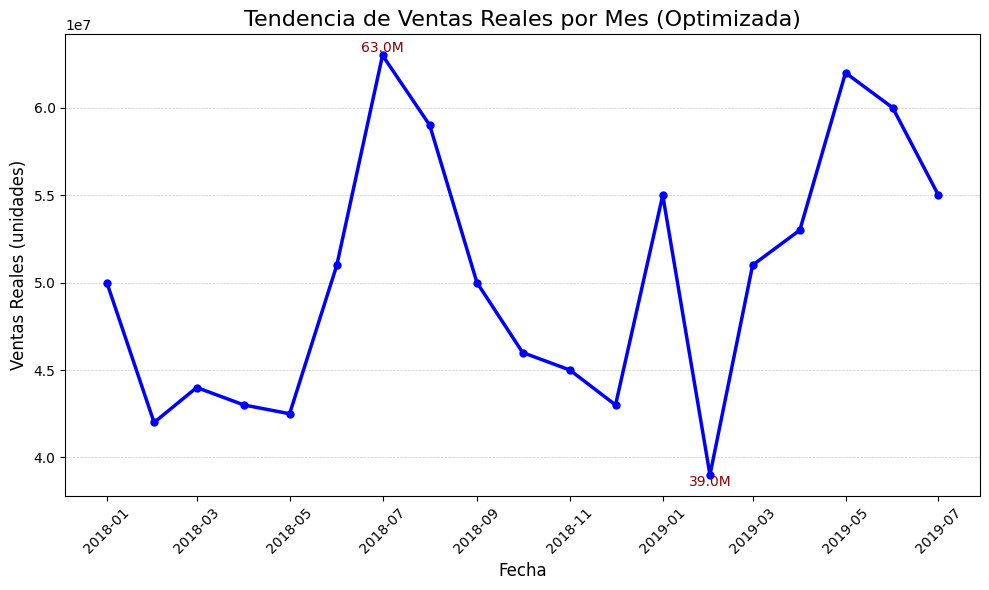

In [31]:
# Visualización optimizada de las ventas reales a lo largo del tiempo

plt.figure(figsize=(10, 6))
plt.plot(sales_data["Fecha"], sales_data["Ventas Reales (unidades)"], color='blue', marker='o', linewidth=2.5, markersize=5)

# Títulos y etiquetas mejoradas
plt.title("Tendencia de Ventas Reales por Mes (Optimizada)", fontsize=16)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Ventas Reales (unidades)", fontsize=12)

# Ajustes de ejes y etiquetas de valores en puntos clave
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Etiquetas en puntos clave para destacar los valores más altos
for i, value in enumerate(sales_data["Ventas Reales (unidades)"]):
    if value == sales_data["Ventas Reales (unidades)"].max() or value == sales_data["Ventas Reales (unidades)"].min():
        plt.text(sales_data["Fecha"][i], value, f'{value/1e6:.1f}M', ha='center', va='bottom' if value == sales_data["Ventas Reales (unidades)"].max() else 'top',
                 fontsize=10, color="darkred")

# Mejorar la visibilidad de la cuadrícula
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Mostrar la visualización optimizada
plt.tight_layout()
plt.show()


#### Comparación
La visualización básica es útil, pero carece de detalles que guíen la interpretación.
La visualización optimizada resalta las variaciones clave y mejora la claridad general, reduciendo la carga cognitiva.

In [33]:
# Revisar y limpiar el dataset asegurando que no haya valores NaN o valores no numéricos en las columnas clave

# Confirmar que "Ventas Reales (unidades)" es numérico y eliminar cualquier valor que no se pueda convertir
sales_data["Ventas Reales (unidades)"] = pd.to_numeric(sales_data["Ventas Reales (unidades)"], errors='coerce')
sales_data = sales_data.dropna(subset=["Ventas Reales (unidades)"])  # Eliminar cualquier NaN en la columna de ventas

# Asegurarse de que "Fecha" esté en formato datetime, eliminando cualquier fecha inválida
sales_data["Fecha"] = pd.to_datetime(sales_data["Fecha"], errors='coerce')
sales_data = sales_data.dropna(subset=["Fecha"])  # Eliminar cualquier NaT en la columna de fecha

# Verificar nuevamente el estado del dataframe para confirmar la limpieza
sales_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 18
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Fecha                           19 non-null     datetime64[ns]
 1   Ventas Reales (unidades)        19 non-null     float64       
 2   Ventas planificadas (unidades)  7 non-null      float64       
 3   Trimestre                       19 non-null     int32         
 4   Año                             19 non-null     int32         
dtypes: datetime64[ns](1), float64(2), int32(2)
memory usage: 760.0 bytes


In [ ]:
# Filtrar los datos hasta julio de 2019
filtered_sales_data = sales_data[sales_data["Fecha"] <= pd.to_datetime("2019-07-01")]


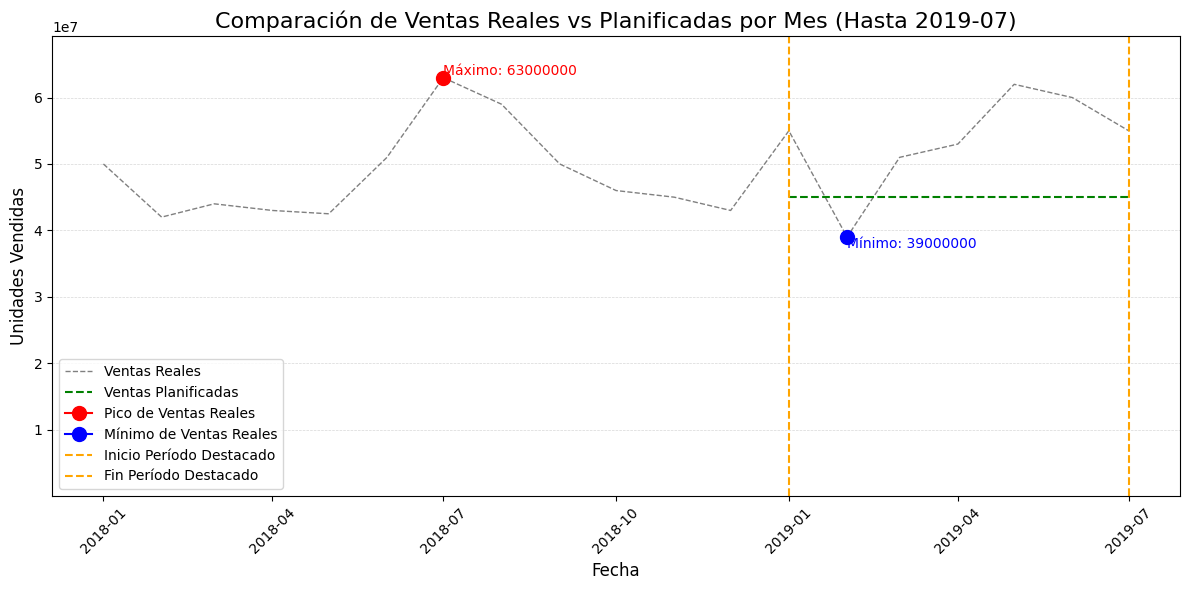

In [42]:
# Importar mdates para el manejo de fechas en el eje x
import matplotlib.dates as mdates

# Intentar nuevamente la visualización con los datos filtrados y el eje x configurado correctamente

plt.figure(figsize=(12, 6))

# Graficar ventas reales
plt.plot(filtered_sales_data["Fecha"], filtered_sales_data["Ventas Reales (unidades)"], color='gray', linewidth=1, linestyle='--', label="Ventas Reales")

# Graficar ventas planificadas
plt.plot(filtered_sales_data["Fecha"], filtered_sales_data["Ventas planificadas (unidades)"], color='green', linewidth=1.5, linestyle='--', label="Ventas Planificadas")

# Resaltar el punto de mayor y menor venta de las ventas reales
max_value = filtered_sales_data["Ventas Reales (unidades)"].max()
min_value = filtered_sales_data["Ventas Reales (unidades)"].min()
max_date = filtered_sales_data["Fecha"][filtered_sales_data["Ventas Reales (unidades)"].idxmax()]
min_date = filtered_sales_data["Fecha"][filtered_sales_data["Ventas Reales (unidades)"].idxmin()]

# Usar color rojo para el valor máximo y azul para el valor mínimo, y añadir etiquetas
plt.plot(max_date, max_value, marker='o', color='red', markersize=10, label="Pico de Ventas Reales")
plt.text(max_date, max_value, f'Máximo: {max_value:.0f}', color='red', ha='left', va='bottom', fontsize=10)

plt.plot(min_date, min_value, marker='o', color='blue', markersize=10, label="Mínimo de Ventas Reales")
plt.text(min_date, min_value, f'Mínimo: {min_value:.0f}', color='blue', ha='left', va='top', fontsize=10)

# Agregar una barra vertical en las fechas de inicio y fin del período destacado
plt.axvline(pd.to_datetime('2019-01-01'), color='orange', linestyle='--', linewidth=1.5, label="Inicio Período Destacado")
plt.axvline(pd.to_datetime('2019-07-01'), color='orange', linestyle='--', linewidth=1.5, label="Fin Período Destacado")

# Ajustar el rango del eje y para comenzar en 1
plt.ylim(1, filtered_sales_data["Ventas Reales (unidades)"].max() * 1.1)

# Ajustar los ticks del eje x para mostrar fechas completas, similar al ejemplo compartido
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))  # Etiquetas cada tres meses
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Títulos y etiquetas
plt.title("Comparación de Ventas Reales vs Planificadas por Mes (Hasta 2019-07)", fontsize=16)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Unidades Vendidas", fontsize=12)
plt.xticks(rotation=45)
plt.legend()

# Cuadrícula para facilitar la comparación
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

# Mostrar la visualización comparativa con los datos filtrados
plt.tight_layout()
plt.show()


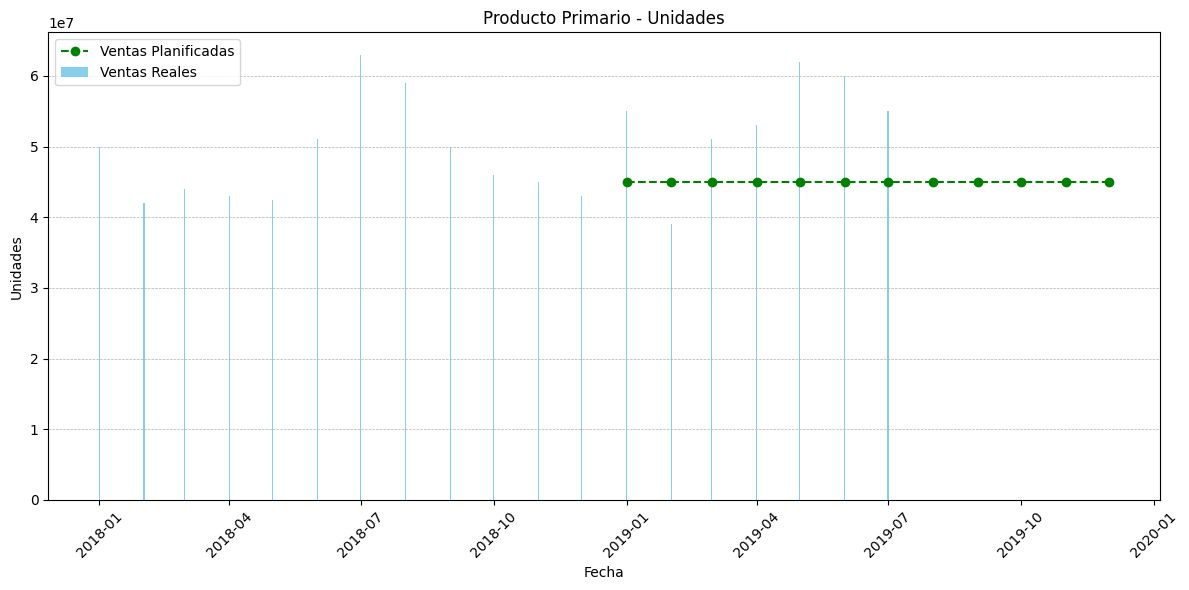

In [43]:
# Mostrar la imagen
Image(filename='./carlos.jpeg')

### Crítica equipo Brian Carrillo y Carlos López

Para mejorar la gráfica, sugiero resaltar los valores máximo y mínimo de ventas con anotaciones claras, lo que facilita la identificación de estos puntos clave. También sería útil agregar líneas de referencia en los periodos destacados, inicio y fin, lo que ayuda a enfocar la atención en momentos específicos. Para distinguir mejor entre ventas planificadas y reales, es recomendable usar colores más contrastantes y estilos de línea diferenciados. Estos ajustes simplifican la interpretación y mejoran la claridad, asegurando que los datos se presenten de forma precisa y fácil de entender, en línea con los principios de Excelencia e Integridad Gráfica.